# 020. Spam Filtering Logistic Regression

- https://www.kaggle.com/uciml/sms-spam-collection-dataset  

- SMS 스팸 컬렉션은 태그가 지정된 SMS 메시지 집합입니다. 여기에는 5,574 개 메시지 중 영어로 된 SMS 메시지 한 세트가 포함되어 있으며 이에 따라 햄 (합법적) 또는 스팸으로 태그가 지정됩니다.

필요한 라이브러리를 import 합니다. 텍스트 데이터 처리와 로지스틱 회귀 분류를 위한 모듈을 사용합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

스팸 데이터셋을 CSV 파일에서 로드합니다. label과 message 컬럼만 사용합니다.

In [3]:
sms = pd.read_csv("datasets/spam.csv", 
                  encoding="ISO-8859-1", 
                  usecols=[0, 1], skiprows=1, 
                  names=["label", "message"])
sms.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


데이터의 라벨 종류를 확인합니다. 'ham'과 'spam' 두 가지가 있습니다.

In [4]:
sms['label'].unique()

array(['ham', 'spam'], dtype=object)

라벨을 숫자로 변환합니다. ham은 0, spam은 1로 매핑하여 이진 분류 문제로 만듭니다.

In [5]:
sms.label = sms.label.map({"ham": 0, "spam": 1})
sms.head(3)

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


변환된 라벨의 분포를 확인합니다. 각 클래스의 샘플 개수를 확인할 수 있습니다.

In [6]:
sms.label.value_counts()

label
0    4825
1     747
Name: count, dtype: int64

### Train / Test split

데이터를 훈련용과 테스트용으로 분할합니다. 메시지 텍스트는 X, 라벨은 y로 분리합니다.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
            train_test_split(sms.message, sms.label, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4457,), (1115,), (4457,), (1115,))

### Create Document Train Matrix

CountVectorizer를 생성합니다. 이 도구는 텍스트를 단어 빈도 행렬로 변환합니다.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

couvec = CountVectorizer()
couvec

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


### Tokenized Train document matrix  생성

훈련 데이터의 텍스트를 단어 빈도 행렬로 변환합니다. 각 문서가 단어들의 출현 횟수로 표현됩니다.

In [9]:
X_train_tokenized = couvec.fit_transform(X_train)
X_train_tokenized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 59107 stored elements and shape (4457, 7723)>

생성된 단어 사전의 크기를 확인합니다. 전체 몇 개의 고유 단어가 있는지 확인합니다.

In [10]:
#A list of feature names.
names = couvec.get_feature_names_out()
print(len(names))
print(names[1000:1100])

7723
['anybody' 'anyhow' 'anymore' 'anyone' 'anyplaces' 'anythiing' 'anythin'
 'anything' 'anythingtomorrow' 'anytime' 'anyway' 'anyways' 'anywhere'
 'aom' 'apart' 'apartment' 'apes' 'apeshit' 'aphexåõs' 'apo' 'apologetic'
 'apologise' 'apologize' 'apology' 'app' 'apparently' 'appeal' 'appear'
 'applausestore' 'applebees' 'apples' 'application' 'apply' 'applyed'
 'appointment' 'appointments' 'appreciate' 'appreciated' 'approaches'
 'appropriate' 'approve' 'approved' 'approx' 'apps' 'appt' 'appy' 'april'
 'aproach' 'aptitude' 'aquarius' 'ar' 'arab' 'arabian' 'arcade' 'archive'
 'ard' 'are' 'area' 'aren' 'arent' 'arestaurant' 'aretaking'
 'areyouunique' 'argentina' 'argh' 'argue' 'arguing' 'argument'
 'arguments' 'aries' 'arise' 'arises' 'arithmetic' 'arm' 'armand'
 'armenia' 'arms' 'arng' 'arngd' 'arnt' 'around' 'aroundn' 'arr' 'arrange'
 'arranging' 'arrested' 'arrival' 'arrive' 'arrived' 'arrow' 'arsenal'
 'art' 'artists' 'arts' 'arul' 'arun' 'as' 'asa' 'asap' 'asda']


In [11]:
import pandas as pd

# feature 이름
feature_names = couvec.get_feature_names_out()

# DataFrame 변환
df_bow = pd.DataFrame(
    X_train_tokenized.toarray(),
    columns=feature_names
)
df_bow.head()

,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,ìï,ó_,û_,ûªm,ûªt,ûªve,ûï,ûïharry,ûò,ûówell
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


테스트 데이터도 동일한 단어 사전을 사용하여 변환합니다. 훈련 시 학습한 단어 사전을 그대로 사용합니다.

In [12]:
X_test_tokenized = couvec.transform(X_test)
X_test_tokenized

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 13784 stored elements and shape (1115, 7723)>

로지스틱 회귀 분류기를 생성하고 훈련 데이터로 학습시킵니다. 텍스트의 단어 패턴을 학습하여 스팸을 구분합니다.

In [14]:
lr_classifier = LogisticRegression(random_state=0)
lr_classifier.fit(X_train_tokenized, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

### predict

- predict() - 예측된 class 를 threshold 0.5 기준으로 반환
- predict_proba() - class 별 probability 를 반환

학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다. 각 메시지가 스팸(1)인지 햄(0)인지 분류합니다.

In [15]:
y_pred = lr_classifier.predict(X_test_tokenized)

print(y_pred)
print()
print("Test set 의 true counts = ", sum(y_test))
print("모델이 예측한 predicted true counts = ", sum(y_pred))
print("accuracy = {:.2f}".format(sum(y_pred == y_test) / len(y_test)))

[0 0 0 ... 0 0 0]

Test set 의 true counts =  143
모델이 예측한 predicted true counts =  129
accuracy = 0.99


## confusion matrix 를 이용한 model 평가

평가 지표를 계산하기 위한 함수들을 import 합니다. confusion matrix와 다양한 성능 지표를 사용합니다.

In [16]:
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.metrics import  accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict
import seaborn as sns

혼동 행렬을 계산하고 시각화합니다. 실제 라벨과 예측 라벨의 일치 여부를 확인할 수 있습니다.

Confusion Matrix:
[[129  14]
 [  0 972]]


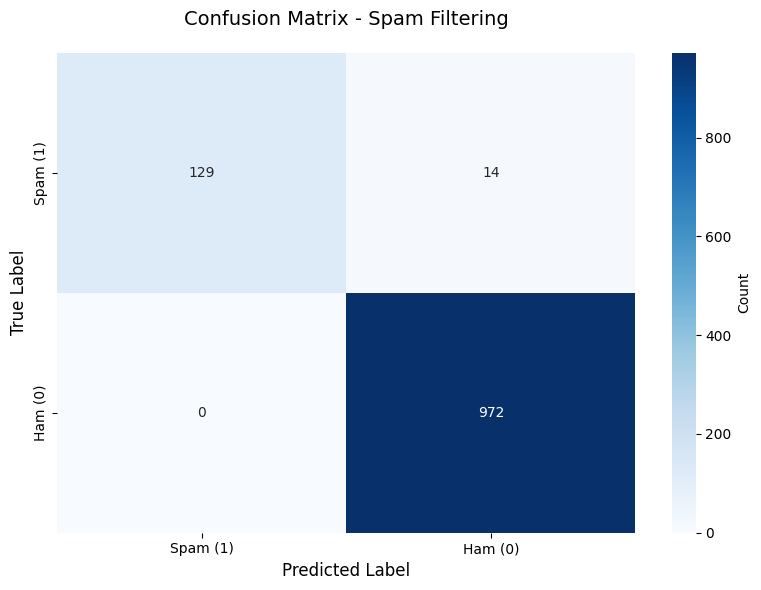


Confusion Matrix 해석:
True Positive (TP): 129 - 스팸을 스팸으로 정확히 예측
False Positive (FP): 14 - 햄을 스팸으로 잘못 예측
False Negative (FN): 0 - 스팸을 햄으로 잘못 예측
True Negative (TN): 972 - 햄을 햄으로 정확히 예측


In [17]:
cm  = confusion_matrix(y_test, y_pred, labels=[1, 0])

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

# 더 명확한 시각화
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Spam (1)', 'Ham (0)'],
                 yticklabels=['Spam (1)', 'Ham (0)'],
                 cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Spam Filtering', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 각 셀의 의미 설명
print("\nConfusion Matrix 해석:")
print(f"True Positive (TP): {cm[0,0]} - 스팸을 스팸으로 정확히 예측")
print(f"False Positive (FP): {cm[0,1]} - 햄을 스팸으로 잘못 예측")
print(f"False Negative (FN): {cm[1,0]} - 스팸을 햄으로 잘못 예측")
print(f"True Negative (TN): {cm[1,1]} - 햄을 햄으로 정확히 예측")

정확도, 정밀도, 재현율, F1 점수를 계산하여 모델의 성능을 종합적으로 평가합니다.

In [18]:
print("Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.2f}".format(precision_score(y_test, y_pred, labels=[1, 0])))
print("Recall: {:.2f}".format(recall_score(y_test, y_pred, labels=[1, 0])))
print("f1 score\n", f1_score(y_test, y_pred))

Accuracy: 0.99
Precision: 1.00
Recall: 0.90
f1 score
 0.9485294117647058
